<a href="https://colab.research.google.com/github/Anuj2606/Skip-Connection-U-Net-Segmentation-Quality/blob/main/Skip_Connections_in_U_Net_A_Segmentation_Ablation_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

# 1. Enable CUDA GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using compute device: {device}")

# 2. Data Transformations and Target Normalization (-1 to map 1,2,3 -> 0,1,2)
transform_img = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
])

transform_target = T.Compose([
    T.Resize((128, 128), interpolation=T.InterpolationMode.NEAREST),
    T.PILToTensor(),
    T.Lambda(lambda x: (x.squeeze().long() - 1))
])

# 3. Load Oxford-IIIT Pet Dataset
print("Downloading Oxford-IIIT Pet Dataset...")
train_dataset = torchvision.datasets.OxfordIIITPet(
    root="./data", split="trainval", target_types="segmentation",
    download=True, transform=transform_img, target_transform=transform_target
)

test_dataset = torchvision.datasets.OxfordIIITPet(
    root="./data", split="test", target_types="segmentation",
    download=True, transform=transform_img, target_transform=transform_target
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Using compute device: cuda


100%|██████████| 792M/792M [00:36<00:00, 21.5MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.26MB/s]


In [ ]:
# Model A: Simple Encoder-Decoder (Without Skip Connections)
class SimpleEncoderDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), nn.ReLU(),
            nn.Conv2d(32, 3, kernel_size=1)
        )

    def forward(self, x):
        x = self.encoder(x)
        return self.decoder(x)

# Model B: U-Net Architecture (With Skip Connections)
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.Conv2d(128, 128, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.ReLU())

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(256, 128, 3, padding=1), nn.ReLU())

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.ReLU())
        self.out_conv = nn.Conv2d(64, 3, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1) # Skip Connection
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1) # Skip Connection
        d1 = self.dec1(d1)

        return self.out_conv(d1)

# Training Helper Function
def train_model(model, loader, epochs=3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(loader):.4f}")
    return model

print("--- Training Simple Encoder-Decoder ---")
simple_model = train_model(SimpleEncoderDecoder(), train_loader, epochs=3)

print("\n--- Training U-Net (With Skip Connections) ---")
unet_model = train_model(UNet(), train_loader, epochs=3)

--- Training Simple Encoder-Decoder ---
Epoch 1/3 - Loss: 0.8962
Epoch 2/3 - Loss: 0.7822
Epoch 3/3 - Loss: 0.7461

--- Training U-Net (With Skip Connections) ---
Epoch 1/3 - Loss: 0.8339
Epoch 2/3 - Loss: 0.7030
Epoch 3/3 - Loss: 0.6224


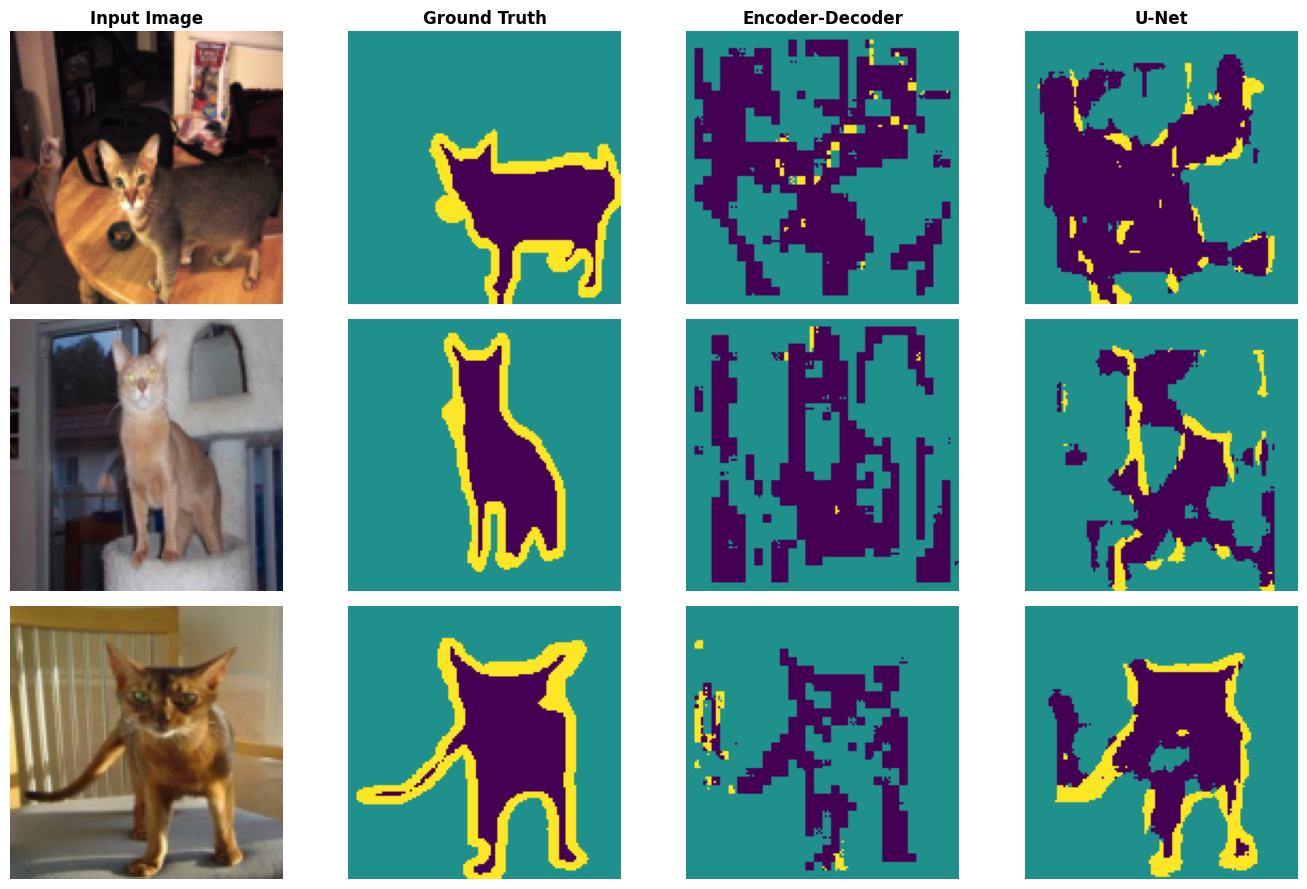

In [ ]:
model_simple = simple_model.eval()
model_unet = unet_model.eval()

images, masks = next(iter(test_loader))
images, masks = images.to(device), masks.to(device)

with torch.no_grad():
    preds_simple = torch.argmax(model_simple(images), dim=1)
    preds_unet = torch.argmax(model_unet(images), dim=1)

# Plotting 3 Samples
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
titles = ["Input Image", "Ground Truth", "Encoder-Decoder", "U-Net"]

for i in range(3):
    img = images[i].cpu().permute(1, 2, 0)
    gt = masks[i].cpu()
    p_sim = preds_simple[i].cpu()
    p_un = preds_unet[i].cpu()

    axes[i, 0].imshow(img)
    axes[i, 1].imshow(gt, cmap='viridis')
    axes[i, 2].imshow(p_sim, cmap='viridis')
    axes[i, 3].imshow(p_un, cmap='viridis')

for ax, t in zip(axes[0], titles):
    ax.set_title(t, fontsize=12, fontweight='bold')

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def compute_metrics_fast(model, loader, num_classes=3):
    model.eval()
    total_iou = 0.0
    total_dice = 0.0
    total_batches = 0
    smooth = 1e-6

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = torch.argmax(model(images), dim=1)

            # Vectorized multi-class metric calculation across batch
            for cls in range(num_classes):
                pred_cls = (preds == cls)
                mask_cls = (masks == cls)

                intersection = (pred_cls & mask_cls).sum(dim=(1, 2)).float()
                union = (pred_cls | mask_cls).sum(dim=(1, 2)).float()
                total_sum = pred_cls.sum(dim=(1, 2)) + mask_cls.sum(dim=(1, 2)).float()

                iou = (intersection + smooth) / (union + smooth)
                dice = (2.0 * intersection + smooth) / (total_sum + smooth)

                total_iou += iou.mean().item()
                total_dice += dice.mean().item()

            total_batches += 1

    mean_iou = total_iou / (total_batches * num_classes)
    mean_dice = total_dice / (total_batches * num_classes)
    return mean_iou, mean_dice

# Re-instantiate DataLoader with parallel workers
test_loader_fast = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

simple_iou, simple_dice = compute_metrics_fast(simple_model, test_loader_fast)
unet_iou, unet_dice = compute_metrics_fast(unet_model, test_loader_fast)

print(f"Simple Encoder-Decoder -> Mean IoU: {simple_iou:.4f} | Dice Score: {simple_dice:.4f}")
print(f"U-Net                   -> Mean IoU: {unet_iou:.4f} | Dice Score: {unet_dice:.4f}")

Simple Encoder-Decoder -> Mean IoU: 0.3441 | Dice Score: 0.4451
U-Net                   -> Mean IoU: 0.4879 | Dice Score: 0.6173


In [ ]:
class DiceCELoss(nn.Module):
    def __init__(self, num_classes=3, smooth=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth
        self.ce = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)

        probs = torch.softmax(inputs, dim=1)
        targets_one_hot = torch.nn.functional.one_hot(targets, num_classes=self.num_classes).permute(0, 3, 1, 2)

        intersection = (probs * targets_one_hot).sum(dim=(2, 3))
        cardinality = probs.sum(dim=(2, 3)) + targets_one_hot.sum(dim=(2, 3))

        dice_loss = 1.0 - ((2.0 * intersection + self.smooth) / (cardinality + self.smooth)).mean()
        return ce_loss + dice_loss


In [ ]:
# 1. Instantiate the Combined Loss Function
criterion = DiceCELoss(num_classes=3)

# 2. Updated Training Function
def train_model_with_dice_ce(model, loader, epochs=5, lr=1e-3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = DiceCELoss(num_classes=3)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(loader)
        print(f"Epoch {epoch+1}/{epochs} - Combined Loss: {avg_loss:.4f}")

    return model

# 3. Train U-Net with Combined Loss
print("--- Retraining U-Net with Combined Dice + Cross-Entropy Loss ---")
unet_model_dice = train_model_with_dice_ce(UNet(), train_loader, epochs=5)

# 4. Re-evaluate Metrics
unet_iou_new, unet_dice_new = compute_metrics_fast(unet_model_dice, test_loader_fast)
print(f"\nUpdated U-Net -> Mean IoU: {unet_iou_new:.4f} | Dice Score: {unet_dice_new:.4f}")


--- Retraining U-Net with Combined Dice + Cross-Entropy Loss ---
Epoch 1/5 - Combined Loss: 1.4266
Epoch 2/5 - Combined Loss: 1.2243
Epoch 3/5 - Combined Loss: 1.1104
Epoch 4/5 - Combined Loss: 1.0068
Epoch 5/5 - Combined Loss: 0.9615

Updated U-Net -> Mean IoU: 0.5592 | Dice Score: 0.6890
